# Representing geographic data as networks

As we briefly introduced in Chapter 5.2, networks are data structures that consists of nodes that are connected to other nodes via edges which ultimately construct a network topology (or a graph as it is referred in graph theory). In this section, we will show how you can construct spatial networks using Python based on geographic data. We will show how you can create a simple graph from scratch, as well as how to create a network from a given dataset with `LineString` objects or from OpenStreetMap data that makes it possible to create networks from all over the world that can be used for various network analysis purposes.

## What is a network?

As networks are widely used in various domains, the terminology related to networks can sometimes be a bit confusing. To clarify some of the ambiguity related to the terminology, we will explain some common network-related terminology along the way to make it clear how we refer to specific concepts in this book emphasizing the linkage to GIS. Most of the terminology is derived from graph theory and network theory.

`Graph` is a collection of `nodes` and `edges` that constitute a graph structure. A `graph` is an abstract concept commonly used e.g. in mathematics and computer science which emphasizes the connections and relationships between entities (nodes) rather than exact geographic positions or distances. This graph structure is also called as `network topology`. A `network` then again is sometimes defined as **a  graph with attributes**, whereas `spatial network` is a `network` that is used to represent real-world systems on a geographic space. For example, street network is typically not only represented as a collection of `nodes` (intersections) and `edges` (streets) but there are various additional attributes associated with the network, such as length, speed limit, number of lanes, the location of crossroads etc. In practice, the terms `graph`, `network` and `spatial network` are often used in synonymous manner, although there can be subtle differences in terms of how they are defined in different contexts. In this book, we will broadly use the term `graph` when talking about any of these concepts. After all, all of these concepts are graph structures, regardless of whether they have attribute information or not.

In the following, we will dive deeper to all of these aspects and construct various types of networks which aim to make it easier to understand how all of this works using Python. We recommend to start by reading through the section 8.1.2 because this section introduces fundamental concepts related to graphs and various useful functionalities of the `networkx` library. 

## Creating a graph from scratch

In the following sections, we will show how you can create a simple 1) undirected and 2) directed graph from scratch without any specific data source and explain the basic concepts, data structures and methods related to `networkx` library.

### Undirected graph

We will start our exploration with networks by constructing a simple `graph` with `nodes` and `edges` using the `networkx` library. But what is a `node` exactly? A `node` is a point entity that can represent more or less anything in the world, such as a person, computer or location. In GIS context, `node` of a `spatial network` typically refers to a specific location, such as intersection in the street network or a building. In graph theory, `node` is typically called as `vertex`. However, in GIS, we typically differentiate the two: `node` is specific to a point at which a line ends or connects to another line, whereas `vertices` can be in between the `nodes` as intermediate points (Figure 8.1) constructing the shape of a given line geometry (e.g. a curved road). Thus, every `node` of a `graph` can be considered as a `vertex` but not all `vertices` are `nodes`. When working with real-world networks (e.g. street networks), it is typical that the actual geometry of the street segment is simplified when constructing the graph and only the nodes are kept (i.e. the first and last point of LineStrings).

![_**Figure 8.1.** Nodes (in red) and a vertex (blue) extracted from a simple LineString geometry._](../img/node_vs_vertex.png)

_**Figure 8.1.** Nodes (in red) and a vertex (blue) extracted from a simple LineString geometry._

In Python, we can use the `networkx` library and its `nx.Graph()` construct to create an undirected graph. Let's initialize an "empty" graph and store it into a variable `G` that we can later use to populate it with `nodes` and `edges`:

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G

In [2]:
G.nodes

NodeView(())

By calling the `.nodes` attribute, it is possible to return all the nodes of a given graph. As we can see, our graph is still empty without any nodes. We can easily add nodes to our graph by using the `.add_node()` method which can be used to add nodes to a given graph one at a time. In the following, we will add five nodes to our graph and give them simple letter ids from `a` to `e`:

In [3]:
G.add_node("a")
G.add_node("b")
G.add_node("c")
G.add_node("d")
G.add_node("e")

In [4]:
G.nodes.data()

NodeDataView({'a': {}, 'b': {}, 'c': {}, 'd': {}, 'e': {}})

As we see, the graph contains five nodes. By calling the `.nodes.data()` method, we can return not only the nodes of the graph, but also the attributes associated with the nodes. Here, we do not yet have any node attributes associated with our data, which is the reason why we only see empty dictionaries (`{}`) associated with each node. Already at this stage, we can plot our graph even without any edges by using the `nx.draw()` function that is a handy tool to plot `networkx` graph objects (uses `matplotlib` library in the background for plotting):

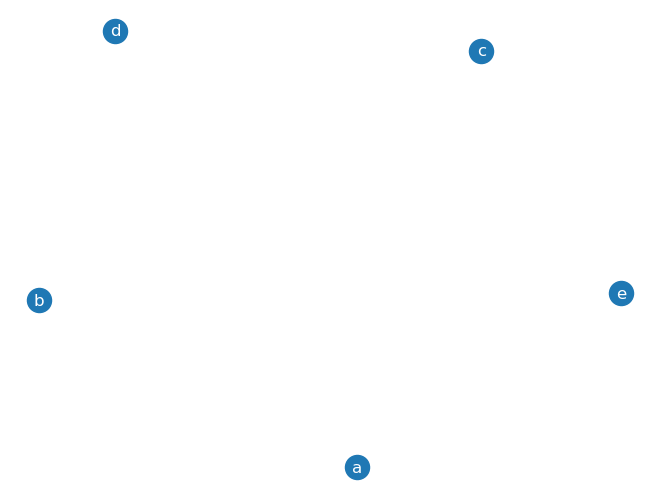

In [5]:
nx.draw(G=G, with_labels=True, font_color="white")

_**Figure 8.1.** Nodes visualized in arbitrary space._

As we can see, at the moment the nodes are located arbitrarily in space because we do not have any specific locations defined for our `nodes`. As mentioned earlier, graphs do not necessarily need any information about the exact locations of the nodes to be able to draw a graph structure. However, the plot above is not yet a graph, because we do not have any edges associated with the nodes that would show how they relate or connect to each other. 

Thus, let's continue by creating `edges` which are the other core element of a graph. A single `edge` is basically a connection between two `nodes`. `Edge` can also be called as `line` or `link` (depending on the context). To create edges, we can use the `.add_edge()` method where we define how the nodes are connected to each other. In `networkx`, the nodes that are connected to each other are often referred as `u` (first node) and `v` (last node). In the following, we will define the topology of our graph by defining one edge at a time how the nodes are connected to each other:

In [6]:
# Add edges            
G.add_edge("a", "b")
G.add_edge("a", "c")
G.add_edge("b", "d")
G.add_edge("c", "d")
G.add_edge("d", "e")

In [7]:
G.edges

EdgeView([('a', 'b'), ('a', 'c'), ('b', 'd'), ('c', 'd'), ('d', 'e')])

As we can see, by accessing the `.edges` we can get a list of node-pairs that construct the connections (i.e. edges) between the nodes. Now we can again plot the graph to see how our network topology looks like:

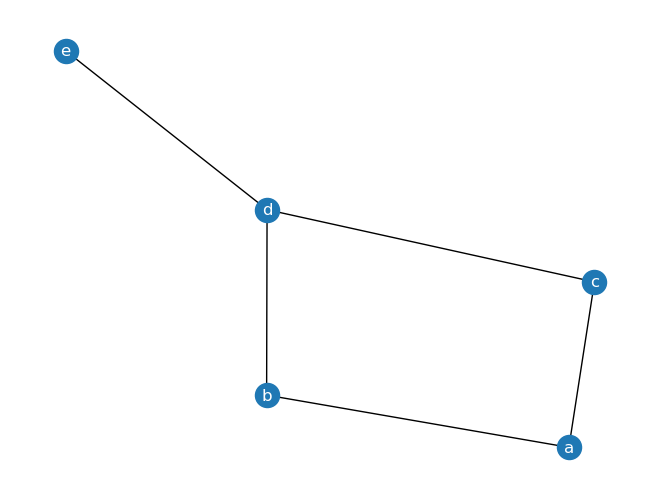

In [8]:
nx.draw(G, with_labels=True, font_color="white")

_**Figure 8.X.** A simple graph with five nodes and edges._

Now we have a very simple graph structure where the nodes are connected to each other as we defined them in the previous step. This kind of graph structure can already be useful for various purposes. If we for example consider that these nodes would represent persons, we could see how those persons are interacting with each other (who knows who). However, as we are mostly interested to study and understand `spatial networks`, let's continue and see how we can present this simple graph in such a way that the locations of the nodes are not in arbitrary space but they have exact locations.

#### Adding node attributes

As mentioned earlier, edges and nodes can have attributes associated with them (e.g. coordinates, distance, volume, capacity) which make them very useful data structure for various analytical purposes, such as conducting way-finding where the target is to find an optimal path between two locations on a network. In the following, we will add the same nodes with ids (`a, b, c, d, e`) but at this time we add coordinates for these nodes as `node attributes`. To do this, we construct a simple data collection that is a `list` of `tuples` where each `tuple` contains the information for a given node. As the first item, we provide the id for a given node (e.g. `"a"`) and as the second item we provide all the node attributes as a Python `dictionary`. In practice, you can add as many node attributes as you like in this `dictionary`, but in our case, we now only add one attribute which we call `"coords"` that will contain the x and y coordinates for a given node: 

In [9]:
node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]

In [10]:
G = nx.Graph()
G.add_nodes_from(node_collection)

We can add this collection of nodes into our `graph` by using the `.add_nodes_from()` method which allows you to add multiple nodes at once without the need to call multiple times `.add_node()` as we did in our previous example. Now, our graph includes not only the nodes, but also the associated attributes as we can see here:

In [11]:
G.nodes.data()

NodeDataView({'a': {'coords': (0, 5)}, 'b': {'coords': (5, 5)}, 'c': {'coords': (0, 0)}, 'd': {'coords': (5, 0)}, 'e': {'coords': (10, 0)}})

#### Adding edge attributes

Adding edges to a given graph with `edge attributes` works in a very similar manner as adding nodes and node attributes as shown previously. When we want to add a collection of edges to a `graph` we create a `list` that contains tuples with information about the connections, i.e. which nodes are linked to each other (e.g. `"a"` and `"b"`), and the edge attributes as a `dictionary`. Here, each `tuple` represents a single edge, where the first and second item corresponds to the connected node-ids and the third item corresponds to the edge attributes. In our case, we add a single edge attribute called `"weight"` which could represent the cost (e.g. distance or time) to move from one node to another, or the importance of a given edge (e.g. the number of people interacting between these nodes in one way or another):

In [12]:
edge_collection = [("a", "b", {"weight": 1}),
                   ("a", "c", {"weight": 1}),
                   ("b", "d", {"weight": 2}),
                   ("c", "d", {"weight": 1}),
                   ("d", "e", {"weight": 3}),
                  ]

Now we can add this collection of edges into our graph `G` by using the `.add_edges_from()` method which can be used to add multiple items at once to the given graph (similar to how we added multiple nodes). As a result, our graph now contains not only the information about the connections (edges), but also the associated `edge attributes`:

In [13]:
G.add_edges_from(edge_collection)
G.edges.data()

EdgeDataView([('a', 'b', {'weight': 1}), ('a', 'c', {'weight': 1}), ('b', 'd', {'weight': 2}), ('c', 'd', {'weight': 1}), ('d', 'e', {'weight': 3})])

#### Visualizing a spatial network

In the previous steps, we prepared a network (a.k.a a graph) that has the necessary information to construct and visualize a (planar) spatial network, where the nodes and edges are not located in arbitrary space but they are tied to our physical world with coordinates. To be able to visualize this spatial network with `networkx`, we first need to extract the coordinates of each node in our graph. We can do this easily by using the `nx.get_node_attributes()` function which will iterate over the nodes and associated node attributes to construct a `dictionary` that contains the node-id as `key` and the coordinate-tuple as `value`:

In [14]:
# Extract node locations
positions = nx.get_node_attributes(G, "coords")
positions

{'a': (0, 5), 'b': (5, 5), 'c': (0, 0), 'd': (5, 0), 'e': (10, 0)}

With this information, we can now draw the network using the `nx.draw()` function similarly as in our previous example. However, now we determine the exact location for every node by using the `pos` parameter that is used to map the nodes to given locations:

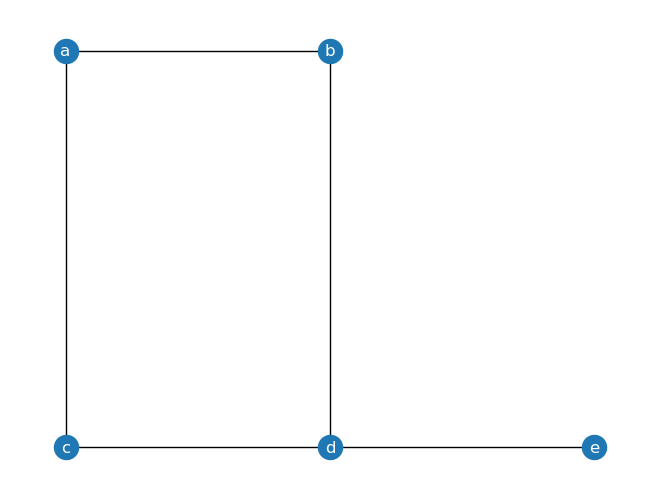

In [15]:
nx.draw(G, pos=positions, with_labels=True, font_color="white")

_**Figure 8.X.** A simple spatial network with five nodes and edges._

Now we have visualized a simple spatial network where the locations of the nodes are pre-determined by us according the coordinates that we used when constructing the graph. Thus, we can be sure that the network always looks exactly the same when we visualize it (which is important for physical real-world networks), which is not the case if visualizing the network without the node coordinates. In fact, if you run the previous code without using the `pos` parameter multiple times, it is likely that you get a different looking graph each time:

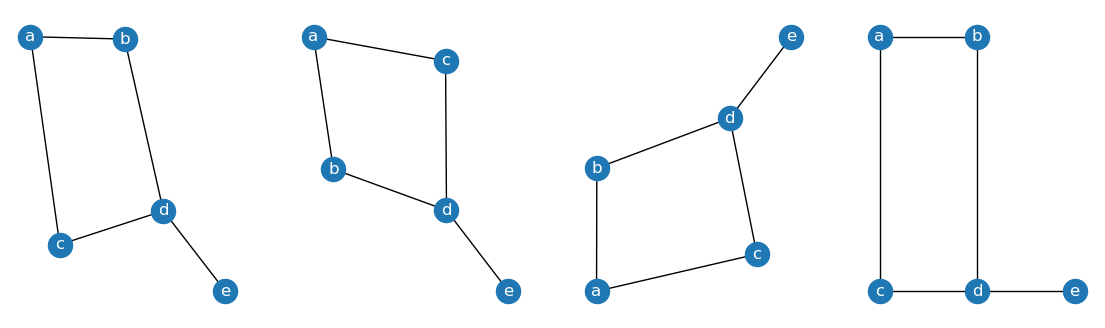

In [16]:
fix, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, figsize=(14,4))

nx.draw(G, with_labels=True, font_color="white", ax=ax1)
nx.draw(G, with_labels=True, font_color="white", ax=ax2)
nx.draw(G, with_labels=True, font_color="white", ax=ax3)
nx.draw(G, pos=positions, with_labels=True, font_color="white", ax=ax4)

_**Figure 8.X.** Defining the node locations ensures that the graph always looks the same (as in the rightmost subplot)._

When we constructed our graph, we also included `edge attributes`. It is also possible to assign colors to edges and/or annotate them according a given edge attribute when visualizing which make it easier to understand the characteristics of our network. To annotate the edges, i.e. show a given edge attribute on top of the edges, we first need to parse the labels that we associate with the edges. We can do this in a very similar manner as how we extracted the node coordinates previously, but in this case we use the `nx.get_edge_attributes()` which returns a `dictionary` containing a tuple of the node-ids of a given edge as a `key` and the edge attribute (here `"weight"`) as the `value`:

In [17]:
# Parse edge labels
weights = nx.get_edge_attributes(G, "weight")
weights

{('a', 'b'): 1, ('a', 'c'): 1, ('b', 'd'): 2, ('c', 'd'): 1, ('d', 'e'): 3}

In [18]:
edge_values = list(weights.values())
edge_values

[1, 1, 2, 1, 3]

Now we can draw the network in such a way that we determine the color of each edge according the `"weight"` attribute and also label the edges so that we can see the actual edge attribute values as well. To determine the color of the edges, we can use the `edge_color` parameter that can be used to determine a single color for all edges or, as in our case, provide a list of values that are mapped to a given color map that we define with the parameter `edge_cmap`. To label the edges, we use the `nx.draw_networkx_edge_labels()` function that draws and positions the labels on top of the graph as follows:

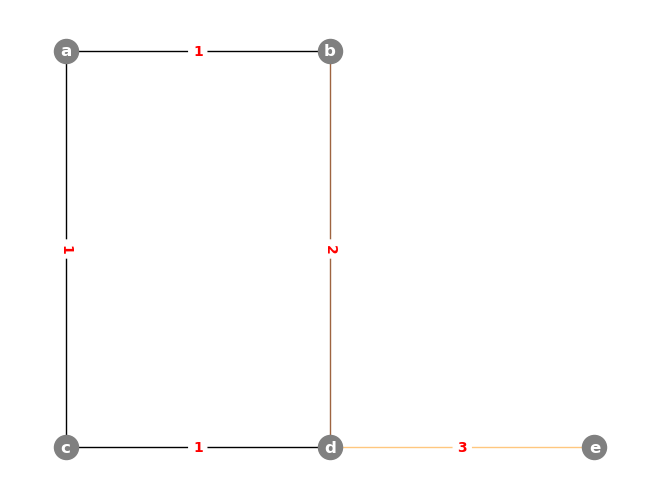

In [19]:
# Draw network with colored edges
nx.draw(G, 
        pos=positions, 
        with_labels=True, 
        font_weight="bold", 
        font_color="white", 
        node_color="grey",
        edge_color=edge_values,
        edge_cmap=plt.cm.copper,
        
)

# Draw edge labels
nx.draw_networkx_edge_labels(
    G, 
    positions,
    edge_labels=weights,
    font_color='red', 
    font_weight="bold",
);

_**Figure 8.X.** A graph with edge labels and colors that are determined by the edge attribute._

### Directed graph

Networks can be `directed` or `undirected`, which determines the `directionality`, i.e. in which direction the nodes are connected to each other. In broad terms, the directionality determines how the interaction happens (or is allowed to happen) between the nodes. In directed graphs, `edges` are always directed, meaning that we need to define the direction how the nodes are connected to each other for each edge. For instance, if we want to have an edge between nodes `A` and `B` that can be traversed in both directions we actually need to construct two edges (called *reciprocal edges*, or sometimes *antiparallel edges*), i.e. one per direction: 1) the node A is connected to node B, and, 2) the node B is connected to node A. We briefly described this logic already in Chapter 5 (see Figure 5.8 and Table 5.1). These kind of directed edges are sometimes called as `arcs`. Some real-world networks where considering the directionality is important include e.g. rivers that flow to specific direction (from upstream to downstream) or a city street network where the travel direction can be restricted to a certain direction in specific parts of the network due to one-way-streets when travelling by car. However, in the context of transport networks do not always need to be directed. Undirected graphs can be used typically for walking or cycling related network analysis, as with those travel modes it is possible to travel the same street in any direction you like (although exceptions exist, such as in Denmark or Netherlands). 

We can create a directed graph with `networkx` in a very similar manner as we did in the previous section when we created an undirected graph. To initialize a directed graph, we can use `networkx`'s `nx.DiGraph()`. In a directed graph, the edge from node `a` to node `b` is stored separately from the edge from `b` to `a`. This means we can represent a two-way street by adding both of these reciprocal edges, and a one-way street by adding only one of them:

In [20]:
G_directed = nx.DiGraph()
G_directed

We can now populate our directed graph with nodes and node attributes in a similar fashion as we did with the undirected graph:

In [21]:
node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]
# Add nodes
G_directed.add_nodes_from(node_collection)
G_directed.nodes.data()

NodeDataView({'a': {'coords': (0, 5)}, 'b': {'coords': (5, 5)}, 'c': {'coords': (0, 0)}, 'd': {'coords': (5, 0)}, 'e': {'coords': (10, 0)}})

However, when constructing the edges, we now need to define a separate edge for each direction. In our case, we create reciprocal edges (i.e. bidirectional connections) everywhere except between the nodes `c` and `d` which we determine to be one-way as shown below. We also add a couple of edge attributes, i.e. `weight` and `color` where the green color indicates a bidirectional edge, and blue represents oneway, respectively. We can again use the `.add_edges_from()` method to add these edges to our graph:

In [22]:
edge_collection = [("a", "b", {"weight": 1, "color": "green"}),
                   ("b", "a", {"weight": 1, "color": "green"}),
                  
                   ("a", "c", {"weight": 1, "color": "green"}),
                   ("c", "a", {"weight": 1, "color": "green"}),
                  
                   ("b", "d", {"weight": 2, "color": "green"}),
                   ("d", "b", {"weight": 2, "color": "green"}),

                   # One-way
                   ("c", "d", {"weight": 1, "color": "blue"}),
                   
                   ("d", "e", {"weight": 3, "color": "green"}),
                   ("e", "d", {"weight": 3, "color": "green"}),
                  ]
# Add edges
G_directed.add_edges_from(edge_collection)
G_directed.edges.data()

OutEdgeDataView([('a', 'b', {'weight': 1, 'color': 'green'}), ('a', 'c', {'weight': 1, 'color': 'green'}), ('b', 'a', {'weight': 1, 'color': 'green'}), ('b', 'd', {'weight': 2, 'color': 'green'}), ('c', 'a', {'weight': 1, 'color': 'green'}), ('c', 'd', {'weight': 1, 'color': 'blue'}), ('d', 'b', {'weight': 2, 'color': 'green'}), ('d', 'e', {'weight': 3, 'color': 'green'}), ('e', 'd', {'weight': 3, 'color': 'green'})])

Great! Now our graph is constructed and we can plot it using the same approaches and methods that we learned in the previous section:

In [23]:
# Extract exact node locations
positions = nx.get_node_attributes(G_directed, "coords")

# Parse edge labels
edge_labels = nx.get_edge_attributes(G_directed, "weight") 

# Parse edge colors
edge_colors = list(nx.get_edge_attributes(G_directed, "color").values())

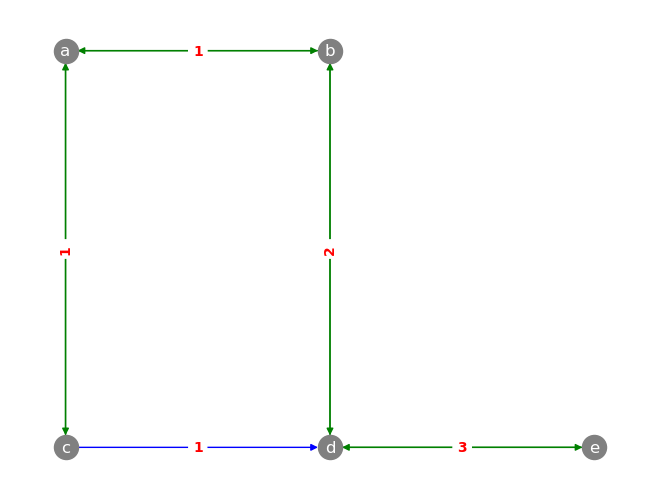

In [24]:
# Draw the graph with edge labels
nx.draw(G_directed, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey",
        edge_color=edge_colors
       )

nx.draw_networkx_edge_labels(
    G_directed, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

_**Figure 8.X.** A directed graph with edge labels showing the weight, and colors and arrows indicating the directionality._

Now our visualized network shows not only the structure of the graph, but also the directionality which we encoded into the graph when constructing it. The small arrows at the end of the lines show the direction how the nodes are connected to each other. As we can see, all edges except the one highlighted with blue color are bidirectional. If we imagine that this network would represent a very simple street network, you could travel the "blue street" only from node `c` to `d` (i.e. a one-way street), whereas all the other streets you can travel to both directions. 

## Creating a graph from geometries

In the previous section, we learned how to create simple "toy graphs" from scratch based on few nodes and edges. However, in real life, you most typically need to create a graph from existing data that can be represented as networks. Some real-life examples include both natural and human-made networks, such as rivers, roads, energy grid, sewers, and so on. In the following, we will learn how to create directed and undirected graphs from existing geographic data. We will use street network here as an example, because streets are one of the most versatile types of networks with various rules and attributes associated with them. However, the same basic principles can be used to various different types of networks, such as the ones mentioned previously. 

### Undirected graph using a GeoDataFrame

Next, we will learn how to create an undirected `networkx` graph from a geographic dataset representing a small sample of streets located in the Helsinki City Centre area that we prepared based on open data fetched from the National Road and Street Database (Digiroad) by Finnish Transport Infrastructure Agency [^digiroad]. The data have been simplified for the purposes of this book, e.g. so that each street segment has a single speed limit value. Let's start by reading the data with `geopandas` into a `GeoDataFrame` called `streets` and explore a bit how it looks like:

In [25]:
import geopandas as gpd
import networkx as nx
from shapely import Point
import matplotlib.pyplot as plt

fp = "data/digiroad_helsinki.gpkg"
streets = gpd.read_file(fp)
streets.head()

,id,direction,maxspeed,road_class,name,geometry
0,0,4,30,4,Uudenmaankatu,"LINESTRING Z (385359.222 6671266.76 8.729, 385..."
1,1,3,40,4,Pitkäsilta,"LINESTRING Z (386282.417 6672754.728 4.562, 38..."
2,2,3,30,5,Kruunuvuorenkatu,"LINESTRING Z (387294.871 6671561.901 2.24, 387..."
3,3,2,30,5,Kristianinkatu,"LINESTRING Z (386646.115 6672721.35 16.528, 38..."
4,4,2,30,5,Fabianinkatu,"LINESTRING Z (386225.349 6671530.049 8.246, 38..."


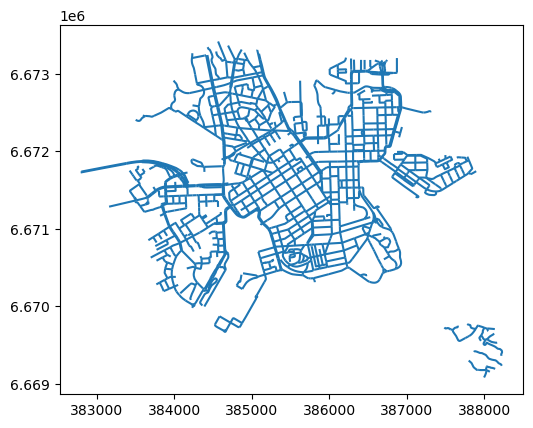

In [26]:
streets.plot();

_**Figure 8.X.** Geographic dataset representing the streets in the Helsinki City Centre area._

As we can see from the table, we have a few columns that provide useful information related to constructing the graph. The most important one of these is the `geometry` column which represents the `LineString` objects of the roads that can be used to create the network topology. In addition, we have useful information related to transport, such as speed limit (`maxspeed`) and the permitted direction of movement (`direction`) map. The map reveals that we have a quite dense network where the streets zigzag across the area connecting different parts of the city to each other. In the South-East corner of the area, we seem have a small part of the network that is not connected to the rest. This part of the network is on an island which lacks a public road connection to the mainland having only a ferry connection that one can take to reach the island (also by car). 

In the following, we will see how to create an undirected graph from this geographic data using the same techniques that we learned previously when constructing a graph from scratch. We will start by introducing a function `gdf_to_graph()` that can be used to turn a `GeoDataFrame` consisting of `LineString` objects into a `nx.Graph` object:

In [27]:
def gdf_to_graph(gdf):
    """Creates a NetworkX Graph from GeoDataFrame consisting of LineString objects.

    Parameters
    ----------

    gdf : GeoDataFrame
        GeoDataFrame containing the LineString data.

    """

    # Create the NetworkX graph
    graph = nx.Graph()
        
    # Generate edge dictionary
    for row in gdf.itertuples():
        coords = row.geometry.coords

        # Get first and last node of the edge (excluding vertices)
        first, last = coords[0], coords[-1]

        # Edge attributes
        edge_attr = row._asdict()

        graph.add_edge(first, last, **edge_attr)

    # Generate node attributes
    node_attrs = {node: {"coords": (node[0], node[1]), "x": node[0], "y": node[1]} for node in graph.nodes}
    nx.set_node_attributes(graph, node_attrs)  
    
    # Relabel the indices
    graph = nx.convert_node_labels_to_integers(graph)

    # Add some useful attributes    
    graph.graph['crs'] = gdf.crs

    return graph

Next, we will go through this function few steps at a time to understand what is happening. Let's start by investigating what happens at the beginning of the function and inside the loop:

In [28]:
graph = nx.Graph()

for row in streets.itertuples():
    # Get the coordinates
    coords = row.geometry.coords

    # Get first and last node of the edge (excluding vertices)
    first, last = coords[0], coords[-1]

    # Get the edge attributes
    edge_attributes = row._asdict()

    # Add to the graph
    graph.add_edge(first, last, **edge_attributes)
    break

Here, we first initialize the `graph` object that is used to store the data and construct the network structure. With `.itertuples()` method (see Chapter 3.3), we can iterate over the rows one by one where each row includes the `geometry` (i.e. a `LineString` object) of a single segment in our street network. The `coords` variable here is used to store the coordinates of the `LineString` vertices. The coordinates of the first `LineString` in our street network look like following:

In [29]:
list(coords)

[(385359.22199999995, 6671266.759999999, 8.729),
 (385388.0329999999, 6671288.834, 8.987),
 (385429.82200000004, 6671317.645999999, 8.732)]

As we can see, there are 3 vertices in this `LineString` object representing a given street. When constructing the graph topology, we only care about the `nodes` of the street segment geometry (i.e. the first and last coordinates of the geometry). This means that in case there are vertices between the nodes, those will not be taken into consideration in the topology of the graph (unless specifically needed for some special use case). Thus, the network topology itself does not need to have the full geometry of the street segments for it to work. 

<Axes: >

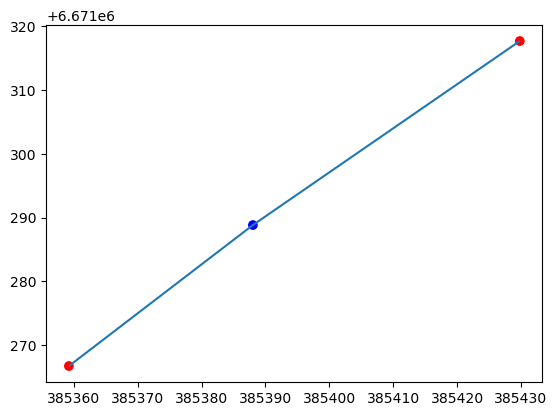

In [30]:
# Create a GeoDataFrame out of the vertices
vertices = gpd.GeoDataFrame(geometry=[Point(coordpair) for coordpair in coords])

fig, ax = plt.subplots()
streets.iloc[0:1].plot(ax=ax)
vertices.plot(ax=ax, color=["r", "b", "r"])

_**Figure 8.X.** Only the nodes (in red) will be used to construct the edge for a given network topology._

Considering only the nodes (ignoring the vertices) has also computational benefits as we ultimately reduce the size of the graph which makes it faster to run any analyses on it. Thus, we only take the first and last coordinate-pair of the edge geometry which we will use as nodes:

In [31]:
print("First node:", first)
print("Last node:", last)

First node: (385359.22199999995, 6671266.759999999, 8.729)
Last node: (385429.82200000004, 6671317.645999999, 8.732)


Although the network topology only considers the nodes, this does not mean that you would loose the actual geometries of the street network, as we can still store the full geometry as an edge attribute to our graph. The `edge_attributes` variable contains all the associated information from the given row as a dictionary:

In [32]:
edge_attributes

{'Index': 0,
 'id': 0,
 'direction': 4,
 'maxspeed': 30,
 'road_class': 4,
 'name': 'Uudenmaankatu',
 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>}

When we call the `graph.add_edge(first, last, **edge_attributes)`, we add this edge to the given `graph`. The `**edge_attributes` command unpacks the values of the dictionary and inserts them as attributes for the given edge. Thus, when we investigate the contents of the edges at this point in time, we will see that the actual `geometry` is also stored for the edge:

In [33]:
graph.edges.data()

EdgeDataView([((385359.22199999995, 6671266.759999999, 8.729), (385429.82200000004, 6671317.645999999, 8.732), {'Index': 0, 'id': 0, 'direction': 4, 'maxspeed': 30, 'road_class': 4, 'name': 'Uudenmaankatu', 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>})])

At this point, you might wonder what happened with the `nodes` as we did not specifically add them to the graph in a similar manner as in our earlier examples? We can investigate how the `nodes` look like at this stage:

In [34]:
graph.nodes.data()

NodeDataView({(385359.22199999995, 6671266.759999999, 8.729): {}, (385429.82200000004, 6671317.645999999, 8.732): {}})

As we can see, `networkx` has actually added the nodes automatically to the graph when we called the `.add_edge()` method based on the information we used to construct a given edge. Because we are using the `LineString` coordinates to construct our graph, the node ids look a bit strange at this point. For instance, the id of the first node in our graph looks like `(385359.22199999995, 6671266.759999999, 8.729)` which is a tuple consisting of three coordinates (x, y and z) represented with many decimal places. This kind of id for a node is very cumbersome to use, but we will soon see how to deal with this issue. Another observation that we can make here is the fact that these nodes do not yet contain any attribute information as we only have empty dictionaries associated with all the nodes. Luckily, it is possible to set the node attributes also after the topology has been constructed. To do this, we can for instance parse the coordinates of the nodes and store this information as node attributes using the `nx.set_node_attributes()`:

In [35]:
# Create a dictionary that contain the node attributes
node_attrs = {node: {"coords": (node[0], node[1]), "x": node[0], "y": node[1]} for node in graph.nodes}
nx.set_node_attributes(graph, node_attrs)  

In [36]:
graph.nodes.data()

NodeDataView({(385359.22199999995, 6671266.759999999, 8.729): {'coords': (385359.22199999995, 6671266.759999999), 'x': 385359.22199999995, 'y': 6671266.759999999}, (385429.82200000004, 6671317.645999999, 8.732): {'coords': (385429.82200000004, 6671317.645999999), 'x': 385429.82200000004, 'y': 6671317.645999999}})

As we can see, now the `nodes` of our graph includes three attributes that provide information about the location of the nodes: `coords`, `x` and `y`. Here, we dropped out the `z` coordinate from the `coords` attribute as `networkx` (nor `geopandas`) cannot handle 3D geometries properly e.g. when visualizing the data.

Now after extracting useful coordinate information from the nodes, we can convert the node ids to be something more intuitive than these complicated coordinate tuples. Luckily, it is easy to relabel the node ids into simple integer values by using the `nx.convert_node_labels_to_integers()` function as follows:

In [37]:
graph = nx.convert_node_labels_to_integers(graph)

In [38]:
graph.edges.data()

EdgeDataView([(0, 1, {'Index': 0, 'id': 0, 'direction': 4, 'maxspeed': 30, 'road_class': 4, 'name': 'Uudenmaankatu', 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>})])

In [39]:
graph.nodes.data()

NodeDataView({0: {'coords': (385359.22199999995, 6671266.759999999), 'x': 385359.22199999995, 'y': 6671266.759999999}, 1: {'coords': (385429.82200000004, 6671317.645999999), 'x': 385429.82200000004, 'y': 6671317.645999999}})

As we can see, now the ids for the nodes were altered from long coordinate tuples into simple integers (such as `0` and `1`) both for the `edges` and `nodes` which are much easier to understand and use if you e.g. want to select specific node from the graph. 

As a very last thing in our `gdf_to_graph()` function, we add a custom attribute to our graph where we store the coordinate reference system information of the input `GeoDataFrame` which can be useful information when using the given graph for analysis with other datasets:

In [40]:
graph.graph["crs"] = streets.crs
graph.graph["crs"]

<Projected CRS: EPSG:3067>
Name: EUREF-FIN / TM35FIN(E,N)
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Finland - onshore and offshore.
- bounds: (19.08, 58.84, 31.59, 70.09)
Coordinate Operation:
- name: TM35FIN
- method: Transverse Mercator
Datum: EUREF-FIN
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

That's it! This is how you can create an undirected graph based on a given `GeoDataFrame` that consists of `LineString` objects. The input data we used here represents streets, but the input data can basically be about anything as long as the geometries of the input data are represented as `LineString` objects. In a similar manner, you could represent e.g. rivers, pipelines, power lines, etc. 

Let's finally use our `gdf_to_graph()` function and create a full network topology based on our `streets` `GeoDataFrame`:

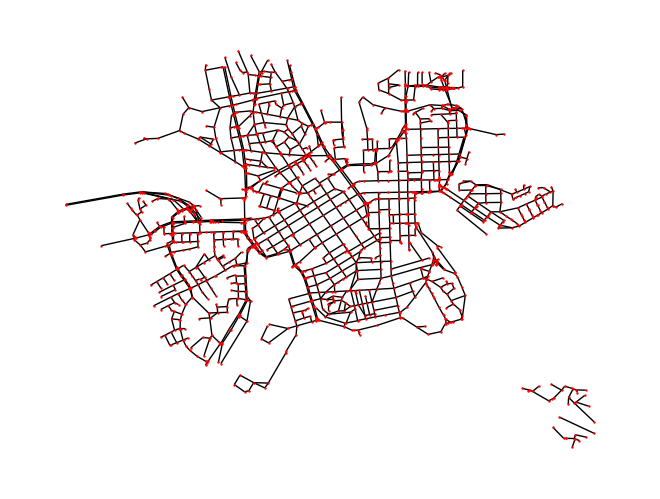

In [41]:
G = gdf_to_graph(streets)

positions = nx.get_node_attributes(G, "coords")

nx.draw(G, 
        pos=positions, 
        node_color="red",
        node_size=0.5,
       )

_**Figure 8.X.** An undirected graph with nodes and edges representing the streets in the Helsinki City Centre area._

### Directed graph using a GeoDataFrame

Now as we have learned how to create a simple undirected graph based on `LineString` geometries, we will continue and expand the previous example to construct a directed graph topology that considers the permitted direction of movement along the streets. When working with street network data and analyzing e.g. the travel times or distances by car, it is necessary to take into consideration one-way streets as those are extremely common especially in larger cities. On these streets, a person can only drive to a specific direction, and if you would need to travel to opposite direction, making an U-turn would not be possible but you would need to travel further to find another path where the driving is permitted to the direction you are heading. Thus, one-way streets can have significant influence on the paths between given locations which need to be taken into account when doing network analysis. If directionality would not be taken into account (like in our previous example), our analyses and results will likely provide incorrect path suggestions and unrealistic results. 

In the following, we will continue working with the same street network as in our previous example but now we will create a directed graph where the permitted direction of travel is taken into consideration. Let's start again by reading the data:

In [42]:
import geopandas as gpd

fp = "data/digiroad_helsinki.gpkg"
streets = gpd.read_file(fp)
streets.head()

,id,direction,maxspeed,road_class,name,geometry
0,0,4,30,4,Uudenmaankatu,"LINESTRING Z (385359.222 6671266.76 8.729, 385..."
1,1,3,40,4,Pitkäsilta,"LINESTRING Z (386282.417 6672754.728 4.562, 38..."
2,2,3,30,5,Kruunuvuorenkatu,"LINESTRING Z (387294.871 6671561.901 2.24, 387..."
3,3,2,30,5,Kristianinkatu,"LINESTRING Z (386646.115 6672721.35 16.528, 38..."
4,4,2,30,5,Fabianinkatu,"LINESTRING Z (386225.349 6671530.049 8.246, 38..."


Here, the `direction` column includes information about the allowed direction of the traffic flow, i.e. whether the traffic is permitted in both directions or whether it is a oneway street. In this street network dataset the values are coded as shown in Table 8.1. As we can see based on these first five rows, there seem to be a couple of street segments that can be travelled to both directions indicated with value `2` (i.e. the edge should be bidirectional). In addition, there are couple of segments where the travel is permitted against the digitization direction (value `3`) and one where the travel is permitted in the direction of digitization. The direction of digitization basically means the order how the vertices (points) of a given `LineString` have been digitized when the data was created. 

: _**Table 8.1**. The rules for directed graph in terms of permitted direction of traffic._

| Value | Direction of traffic flow                                                             |
|-------|---------------------------------------------------------------------------------------|
| 2     | Traffic is permitted in both directions                                               |
| 3     | Traffic is permitted against the direction of digitization (end-node to start-node) |
| 4     | Traffic is permitted in the direction of digitization (start-node to end-node)      |




So far a `DiGraph` has been enough, because in our small example each pair of nodes was connected by at most one edge per direction. Real street data is messier: occasionally two separate road segments connect the same pair of intersections in the same direction — for instance a short direct link and a longer parallel stretch of the same street. A `DiGraph` keeps only one edge per direction between a given pair of nodes, so the second segment would silently overwrite the first and disappear from the network. To keep every segment, we use `nx.MultiDiGraph()`, which allows several edges between the same pair of nodes in the same direction.

Let's start by creating a function called `gdf_to_directed_graph()` which works mostly in a similar manner as our previous function `gdf_to_graph()` but with a few important tweaks that allows us to take into consideration the directionality:

In [43]:
def gdf_to_directed_graph(gdf, direction='direction', both_ways=2, against=3, along=4):
    """Creates a NetworkX MultiDiGraph from road network GeoDataFrame.

    Parameters
    ----------

    gdf : GeoDataFrame
        GeoDataFrame containing the road network data.

    direction : str
        Name for column that contains information about the allowed driving directions

    both_ways : int
        Value specifying that the road is drivable to both directions.

    against : int
        Value specifying that the road is drivable against the digitizing direction.

    along : int
        Value specifying that the road is drivable along the digitizing direction.

    """

    # Create the NetworkX graph
    graph = nx.MultiDiGraph()
        
    # Generate edge dictionary
    for edge in gdf.itertuples():
        coords = edge.geometry.coords

        # Get first and last node of the edge (excluding vertices and possible Z coordinate)
        first, last = coords[0][:2], coords[-1][:2]

        # Edge attributes
        edge_attr = dict(edge._asdict())

        # Create edges according the direction rules
        if edge_attr[direction] == both_ways:

            # If road is bi-directional add it in both ways
            graph.add_edge(first, last, **edge_attr)
            graph.add_edge(last, first, **edge_attr)

        elif edge_attr[direction] == along:

            # Add the edge along digitization direction
            graph.add_edge(first, last, **edge_attr)

        elif edge_attr[direction] == against:
            
            # Add the edge against digitization direction
            graph.add_edge(last, first, **edge_attr)

    # Generate node attributes
    node_attrs = {node: {"coords": (node[0], node[1]), "x": node[0], "y": node[1]} for node in graph.nodes}
    nx.set_node_attributes(graph, node_attrs)  
    
    # Relabel the indices
    graph = nx.convert_node_labels_to_integers(graph)

    # Add some useful attributes    
    graph.graph['crs'] = gdf.crs

    return graph

Here, we added a few parameters to our function, namely `direction` that is used to provide the name of the column in our input `GeoDataFrame` that contains information about which direction a specific edge can be traversed. In addition, we added parameters `both_ways`, `against` and `along` that are used to inform the function about the logic of how the edges should be added to the `graph` following the rules in Table 8.1. Inside the loop, we added a few conditional statements that control the logic how edges are added to the graph. If a specific street segment can be traversed to both directions (i.e. `direction=2` | `direction=both_ways`), we add reciprocal edges, i.e. a separate edge for each direction between the given nodes: 1) from the first node to the last node, and 2) from the last node to the first node. 

In [44]:
G = gdf_to_directed_graph(streets)

In [45]:
positions = {node: attrs["coords"] for node, attrs in G.nodes.data()}

In [46]:
edge_colors = ["blue" if attrs["direction"] == 2 else "red" for u, v, attrs in G.edges.data()]

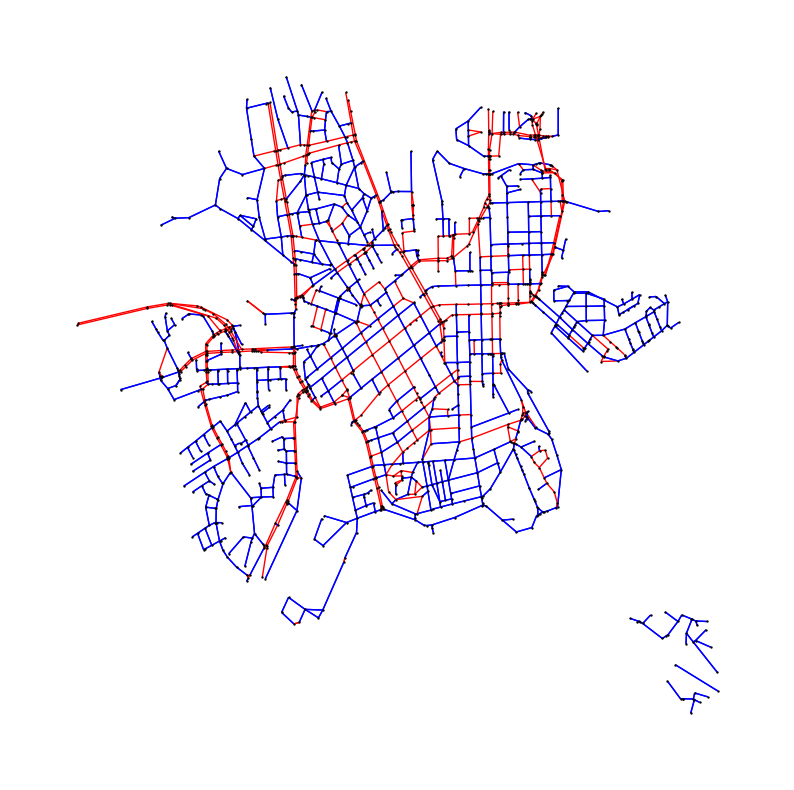

In [47]:
fig, ax = plt.subplots(figsize=(10,10))

nx.draw(G, 
        ax=ax,
        pos=positions, 
        node_color="black",
        node_size=0.5,
        edge_color=edge_colors,
        arrows=False,
       )

_**Figure 8.X.** A directed graph representing the streets in the Helsinki City Centre area, where the edge colors indicate the permitted direction of travel (blue for two-way streets and red for one-way streets)._

## Saving a graph to disk

Once we have constructed a graph, it is often useful to store it on disk so that we do not need to build it again every time we want to use it. This is handy when creating the graph takes a while, or when we want to share the network with others. Saving a graph works in a similar way as saving a `GeoDataFrame` to a file, which we did in Chapter 6.

A `networkx` graph can be written to disk in several different file formats, and the best choice depends on what you want to do with the network afterwards. Table 8.2 summarizes the most common options.

: _**Table 8.2**. Common file formats for saving a `networkx` graph to disk._

| Format | Description |
|:-------|:------------|
| Pickle | Python's own storage format. Saves the graph exactly as it is, including all node and edge attributes (such as the street geometries) and the coordinate reference system. Simple to use, but the files can only be read back in Python. |
| GraphML | A widely used format that can also be opened in other network analysis software, such as Gephi. Supports only simple attribute values (text and numbers), so richer attributes like geometries have to be converted or removed first. |
| GML | A plain-text format that, like GraphML, is understood by many other tools but stores only simple attribute values. |
| JSON | A text-based format that is convenient for web applications, but is likewise limited to values that can be stored as text or numbers. |

For our purposes, we recommend using the `Pickle` format. Our street network stores rich information on its edges — most importantly the `geometry` of each street segment — together with the coordinate reference system of the data. Pickle is the only one of these formats that can store all of this as-is, without us first having to convert or drop any attributes. When we read the graph back, we get an identical copy of the network we saved. The other formats are useful mainly if you want to open the network in a different program, in which case you would first need to reduce the attributes to plain text and numbers.

Let's save our directed street network `G` to disk. We use Python's built-in `pickle` module and write the graph into a file with a `.pickle` ending:

In [51]:
import pickle
from pathlib import Path

output_dir = Path("data")

# Write the graph to disk
output_fp = output_dir / "street_network.pickle"

with open(output_fp, "wb") as f:
    pickle.dump(G, f)

Here, we opened a file in write-binary mode (`"wb"`) and used `pickle.dump()` to store our graph `G` into it. Reading the graph back is just as straightforward — we open the file in read-binary mode (`"rb"`) and use `pickle.load()`:

In [52]:
# Read the graph back from disk
with open(output_fp, "rb") as f:
    G_from_disk = pickle.load(f)

Let's check that the network we read from disk really is the same as the one we saved:

In [53]:
# Compare the reloaded graph with the original one
print("Same number of nodes:", G.number_of_nodes() == G_from_disk.number_of_nodes())
print("Same number of edges:", G.number_of_edges() == G_from_disk.number_of_edges())

Same number of nodes: True
Same number of edges: True


As we can see, the network we read from disk matches the original graph `G`: it contains the same number of nodes and edges. Because we saved the graph in Pickle format, all of the edge attributes — including the street geometries — are preserved as well, which means we can continue working with `G_from_disk` just as we would with the original graph.


## Footnotes

[^digiroad]: <https://vayla.fi/en/transport-network/data/digiroad>